# Adaline (Adaptive Linear Neuron)

In [4]:
import numpy as np

class Adaline:
    def __init__(self,eta=0.01,n_iter = 50,random_state = 50):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
    def fit(self,X,y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0,scale=0.01,size=X.shape[1])
        self.b_ = np.float64(0.0)
        self.losses_ = []

        for _ in range(self.n_iter):
            net_inp = self.net_input(X)
            output = self.activation(net_inp)
            error = (y-output)

            self.w_ += self.eta*2.0*X.T.dot(error)/X.shape[0]
            self.b_ += self.eta*2.0*error.mean()

            loss = (error**2).mean()
            self.losses_.append(loss)

        return self
    def net_input(self,X):
        return np.dot(X,self.w_)+self.b_
    def activation(self,X):
        return X
    def predict(self,X):
        return np.where(self.activation(self.net_input(X))>=0.5,0,1)

In [5]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt

#loading Iris
iris = load_iris(as_frame=True)
df = iris.frame

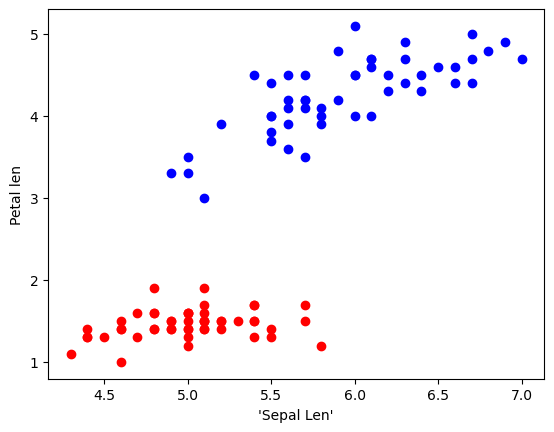

In [22]:
df.head()
y = df.iloc[0:100,4].values #getting only 2 classes data target values
X = df.iloc[0:100,[0,2]].values #getting 2 classes input values

X_std = np.copy(X)
X_std[:,0] = (X[:,0]-X[:,0].mean())/X[:,0].std()
X_std[:,1] = (X[:,1]-X[:,1].mean())/X[:,1].std()

#plotting the both features on scatter plot
plt.scatter(X[:50,0],X[:50,1],color='red') 
plt.scatter(X[50:100,0],X[50:100,1],color='blue')
plt.xlabel("'Sepal Len'")
plt.ylabel("Petal len")
plt.show()

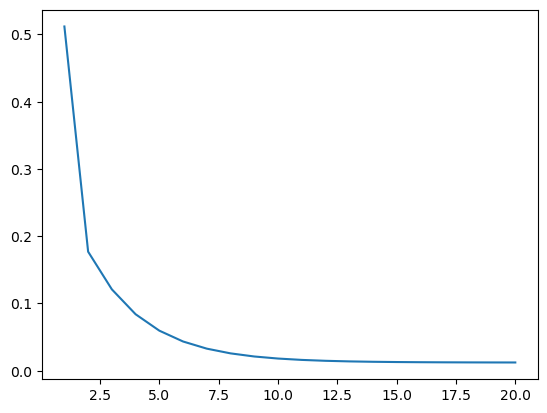

In [24]:
ada = Adaline(eta=0.5,n_iter=20)
ada.fit(X_std,y)
plt.plot(range(1,len(ada.losses_)+1),ada.losses_)